# Human Feedback in the loop
### Adding Human feedback in the chatbot

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State);

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq

groq_api_key=os.getenv("GROQ_API_KEY")
groq_model_name=os.getenv("GROQ_MODEL_NAME")
llm=ChatGroq(groq_api_key=groq_api_key,model_name=groq_model_name)

##### Now let's create tool for human assistance

In [5]:
from langchain_core.tools import tool
from langgraph.types import Command, interrupt

@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

### Now let's create Travily tools

In [6]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

In [8]:
tools=[tool, human_assistance]

# Binding tool with LLM
llm_with_tools=llm.bind_tools(tools)

In [9]:
# Now let's define chatbot
def chatbot(state: State):
    message = llm_with_tools.invoke(state["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    
    return {"messages": [message]}

### Now let's build the graph

In [10]:

from langgraph.prebuilt import ToolNode, tools_condition


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

### Adding memory and compiling the graph

In [11]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

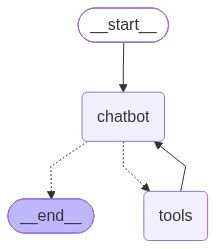

In [12]:
# Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (j9mgcvd3m)
 Call ID: j9mgcvd3m
  Args:
    query: I need expert guidance and assistance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (j9mgcvd3m)
 Call ID: j9mgcvd3m
  Args:
    query: I need expert guidance and assistance for building an AI agent.


##### Here we can see execution is interepted for the human response. So let's give some human response.

In [19]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(
    human_command, 
    config, 
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (p8316v06e)
 Call ID: p8316v06e
  Args:
    query: What are the key features of LangGraph that make it suitable for building an AI agent?
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (0adj16em3)
 Call ID: 0adj16em3
  Args:
    query: How does LangGraph compare to other AI frameworks and tools for building an AI agent?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (0adj16em3)
 Call ID: 0adj16em3
  Args:
    query: How does LangGraph compare to other AI frameworks and tools for build

##### Here we can see execution returned response as :

Name: human_assistance

We, the experts are here to help! We'd recommend


##### But again interepted for the next human response. So let's give some human response again.

In [20]:
human_response = (
    "The main feature of langgraph are : " \
    "Graph-based workflow orchestration," \
    "Persistent state management," \
    "Human in the loop support," \
    "etc."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(
    human_command, 
    config, 
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (0adj16em3)
 Call ID: 0adj16em3
  Args:
    query: How does LangGraph compare to other AI frameworks and tools for building an AI agent?
================================= Tool Message =================================
Name: human_assistance

The main feature of langgraph are : Graph-based workflow orchestration,Persistent state management,Human in the loop support,etc.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (tb0vqad69)
 Call ID: tb0vqad69
  Args:
    query: Are there any specific use cases or applications where LangGraph is particularly well-suited for building an AI agent?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (tb0vqad69)
 Call ID: tb0vqad69
  Args:
    query: Are there any specific use cases or applications where LangGraph is par

# Again it returned response and again interupted for the human response.

### But if we ask for some simple question like about latest news then it doesn't go to human assistance tool and instead it goes to travily tool.

In [22]:
user_input = "What is latest news about USA Iran war?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

What is latest news about USA Iran war?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (asppjdehe)
 Call ID: asppjdehe
  Args:
    query: USA Iran war latest news
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "USA Iran war latest news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/live-updates/iran-war-us-trump-strait-of-hormuz-kuwait-jordan-air-base", "title": "U.S.-Iran negotiations set to begin Monday, Trump says after calling off strikes", "content": "The IRGC's Quds Force oversees Iran's operations abroad, and Guard members killed outside Iran are often affiliated with the unit.\n\nBack in 2020, the U.S. killed the Quds Force's commander, Qasem Soleimani, in an airstrike in Baghdad, along with Hashed 